# Turbine CFD-based Performance Modelling

In [3]:
%load_ext autoreload

%autoreload 2

import gmsh
import pygmsh
import pandas as pd

import matplotlib.pyplot as plt

Author: Elias Aoubala

Date: 

## 1 - Background

This document aims to describe the authors analysis in the CFD of the supersonic turbine stage aimed to be used for the `Man-Ray and the Dirty-Bubble` turbopump. This analysis extends on the mean line design conducted in the `turbine_design.ipynb` document - where a profile had been generated.

We aim to build up a CFD analysis that can be used for validation our mean-line design, coupled with off-nominal performance evaluations of the pump.

In this case, we will be using the following tools:

- **GMSH**: This will be our primary tool that will be used for the meshing of the turbine profile.
- **SU2**: This will be our CFD solver for the analysis.

There are two high level key steps for getting a working turbine stage CFD. In this case its the following:

- Demonstrating the succesful CFD operation of both the turbine and the nozzle individually within our solver enviroment.
- Combining these two with the implementation of a mixing plane assumption + rotating reference frame, for full stage evaluation.

The following sections split up these two procedures accordingly:

## 2 - Individual Component CFD Evaluation

This section has been broken up to two sub-sections, one for the turbine CFD generation, and one for the Nozzle CFD generation.

### 2.1- Turbine Stage Generaiton

The analysis procedure intended is the following:

1. **Geometry Generation of Turbine in GMSH**
   1. We aim here to take our profiles we have generated locally within python, and create GMSH files that we can use for CFD based analysis.
2. **Meshing of the Turbine Profile in GMSH**
   1. We aim here to create a refined mesh with GMSH, such that the number of points is reduced (so run time is fast), and that we can succesfully capture all shock formations and boundary layer growth.
3. **Boundary Condition Defintion within SU2**
   1. Here, we define our relevant boundary conditions for the symetry of the system.
4. **Running the SU2 Simulation**
   1. Here, we simply run the simulation of the turbine, to demonstrate it can converge and get a solution.
5. **Post-processing the SU2 results for parameters of interes**
   1. What we care about here is to be able to extract key parameters of our interest which may include the inlet and exit angels, turbine power, pressure distributions, etc.

Once we are able to demonstrate all of these, we can move on to the Nozzle-element CFD accordingly.

#### 2.1.1 - Loading up our Turbine boundaries

We will firstly load our turbine points, as specified in the following files:

- `cfd_inlet.txt`: Inlet Points of Mesh
- `cfd_outlet.txt`: Outlet Points of Mesh
- `cfd_lower.txt`: Lower Passage Surface
- `cfd_upper.txt`: Upper Passage Surface 

By default, the blade geometries generated output the results in [ mm ], hence a 1e-3 conversion factor is applied at this stage.

We need to firstly define our location where all our profiles are contained

In [4]:
profile_location = "profiles"

In [5]:
cfd_upper = pd.read_csv(f"{profile_location}/cfd_upper.txt", delimiter="\t") * 1e-3
cfd_lower = pd.read_csv(f"{profile_location}/cfd_lower.txt", delimiter="\t") * 1e-3

cfd_inlet = pd.read_csv(f"{profile_location}/cfd_inlet.txt", delimiter="\t") * 1e-3
cfd_outlet = pd.read_csv(f"{profile_location}/cfd_outlet.txt", delimiter="\t") * 1e-3


We can plot these curves to allow visual inspection by the user

Text(0.5, 1.0, 'Blade Passage Profile')

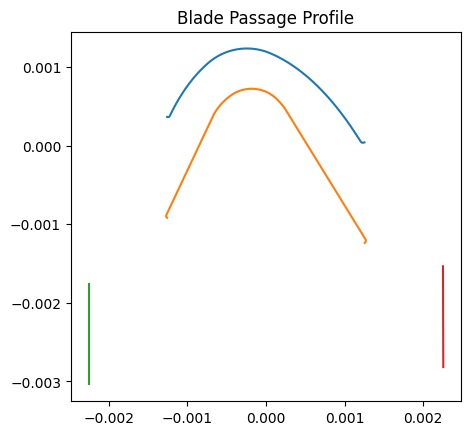

In [7]:
fig, ax = plt.subplots()

ax.plot(cfd_upper["x"], cfd_upper["y"])
ax.plot(cfd_lower["x"], cfd_lower["y"])

ax.plot(cfd_inlet["x"], cfd_inlet["y"])
ax.plot(cfd_outlet["x"], cfd_outlet["y"])
ax.set_aspect(1)
ax.set_title("Blade Passage Profile")

#### 2.1.2 - Mesh Generation

For this mesh, we will use the `py2gmsh` library within python, to allow us to generate a mesh for the blade passage.

We will initially instanatiate our `Mesh` object.

In [8]:
rotor_geometry = pygmsh.geo.Geometry()

We now need to fetch the model within the geometry, that we would like to add our points to.

In [9]:
rotor_model = rotor_geometry.__enter__()

We can now add our geometries to the assembly. To do this, we will first add our rotor blade profile - which in this case will be imported the same way our CAD software will import it.

We will set a global mesh resolution just for the sake of modelling

In [48]:
resolution = 1e-10

cfd_inlet = pd.read_csv(f"{profile_location}/blade.txt", delimiter="\t", header=None) * 1e-3


We will firstly iterate through our points in the data-frame and add then, before then implementing a b-spline across all of them.

In [49]:
blade_points = [
    rotor_model.add_point((cfd_inlet[0][i], cfd_inlet[1][i], cfd_inlet[2][i]), mesh_size=resolution) for i in range(cfd_inlet.__len__() - 1)
]

# We then append the first point to the end accordingly
blade_points.append(blade_points[0])

Exception: Could not get last error

We can now add a B-Spline for us to look at the blade profile:

In [35]:
blade_profile_spline = [rotor_model.add_bspline(blade_points)]

We can now close this loop using the bspline we generated, and generate a curve-loop, letting GMSH know its a closed surface.

In [38]:
blade_profile_loop = rotor_model.add_curve_loop(blade_profile_spline)

We can then add a planar surface accordingly.

In [39]:
surface = rotor_model.add_plane_surface(blade_profile_loop)

We can then generate our mesh

In [40]:
rotor_geometry.generate_mesh(dim=2)

<meshio mesh object>
  Number of points: 4
  Number of cells:
    line: 5
    vertex: 4

And we can then output it to the user.

In [42]:
gmsh.write(f"{profile_location}/mesh.msh")